In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


## Step 1: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


## Step 2: Load the IMDb Dataset 

In [3]:
df = pd.read_csv("/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Step 3: Check class distribution


<Axes: title={'center': 'Class Distribution'}, xlabel='sentiment'>

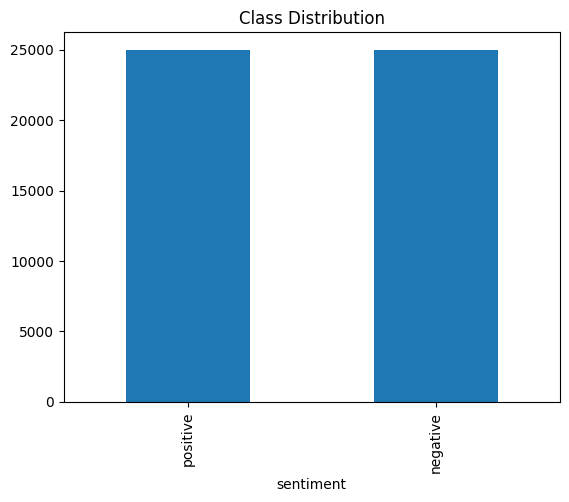

In [4]:
df['sentiment'].value_counts().plot(kind='bar', title='Class Distribution')

## Step 4: Preprocess the Text

In [5]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()  # lowercase
    text = re.sub('<.*?>', '', text)  # remove HTML tags
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)  # remove punctuation
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['clean_review'] = df['review'].apply(preprocess_text)
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


##  Preprocessing (What & Why)

1. **Lowercasing**  
   _All text was converted to lowercase._  
   → Ensures uniformity by avoiding case-based duplicates like “Good” vs “good”.

2. **HTML & Punctuation Removal**  
   _HTML tags and punctuations were stripped from reviews._  
   → Removes noise and irrelevant characters for cleaner tokenization.

3. **Stopword Removal**  
   _Common words like "the", "is", "and" were excluded using NLTK stopwords._  
   → Helps models focus on meaningful content and improve learning.

4. **TF-IDF Vectorization**  
   _Converted text into numerical feature vectors using TF-IDF._  
   → Prioritizes informative words by penalizing frequently occurring but less meaningful terms.

## Step 5: Split the Data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(df['clean_review'], df['label'], test_size=0.2, random_state=42)


## Step 6: Vectorize the Text

In [7]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

##  Models Trained
- Logistic Regression
- Naive Bayes
- Support Vector Machine (SVM)

Each model was trained on 80% of the dataset and tested on 20% using TF-IDF feature vectors.


## Step 7: Train Models

In [8]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_test_tfidf)

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_pred = nb.predict(X_test_tfidf)

# SVM
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)
svm_pred = svm.predict(X_test_tfidf)


## Step 8: Evaluate Models

In [9]:
def evaluate(y_true, y_pred, model_name):
    print(f"🔹 {model_name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("\n")

evaluate(y_test, lr_pred, "Logistic Regression")
evaluate(y_test, nb_pred, "Naive Bayes")
evaluate(y_test, svm_pred, "SVM")


🔹 Logistic Regression
Accuracy: 0.888
Precision: 0.8782088399922795
Recall: 0.9029569358999802
F1 Score: 0.8904109589041096


🔹 Naive Bayes
Accuracy: 0.8511
Precision: 0.8502367797947908
Recall: 0.8551299861083548
F1 Score: 0.8526763629167904


🔹 SVM
Accuracy: 0.8817
Precision: 0.8745143745143745
Recall: 0.89343123635642
F1 Score: 0.8838716010601747




## Step 9: Confusion Matrix Visualization

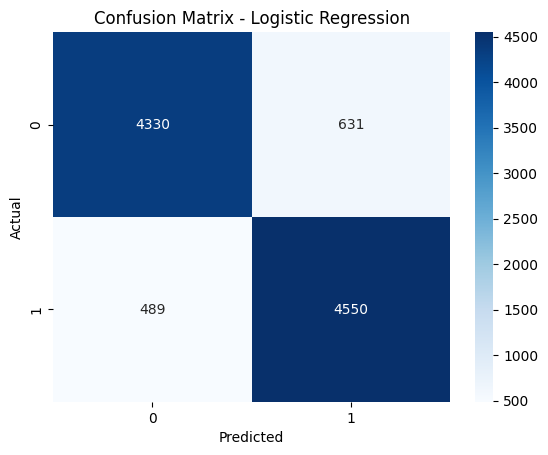

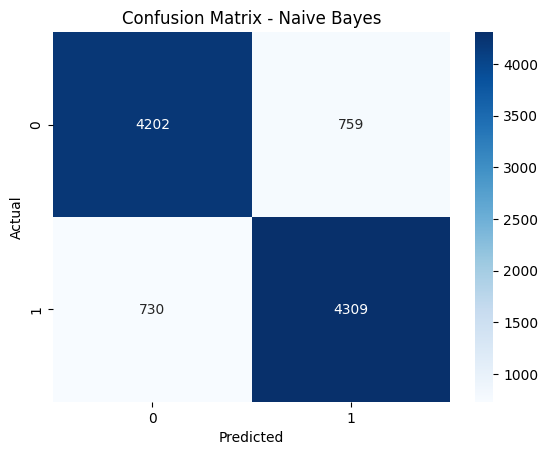

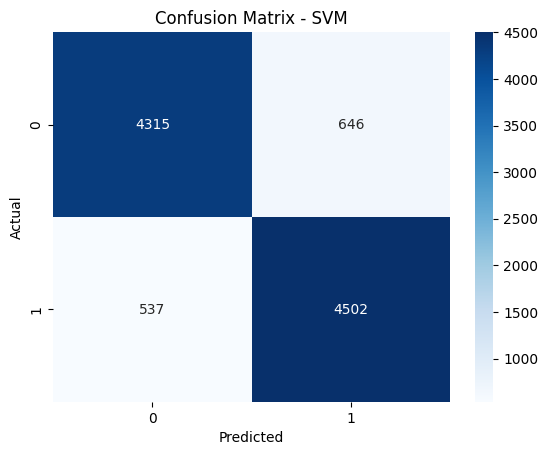

In [10]:
def plot_confusion(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion(y_test, lr_pred, "Logistic Regression")
plot_confusion(y_test, nb_pred, "Naive Bayes")
plot_confusion(y_test, svm_pred, "SVM")


## Insights

- **Logistic Regression** gave the best balance of precision and recall, making it a strong baseline model.
- **Naive Bayes** performed well and is very fast but slightly less accurate due to its simplifying assumptions.
- **SVM** achieved high performance, close to Logistic Regression, and is particularly effective for high-dimensional data like TF-IDF vectors.